# AI Trading Bot Optimisation: A Comparative Metaheuristic Analysis

## Students

- Fabian Gomez Cadena - 24554819
- Yiyuan Ouyang - 24554686
- Lingxiao Ma - 24526617
- Siyi Ma - 24533441

## Project Overview

This notebook develops and evaluates an AI-driven algorithmic trading bot for Bitcoin. The bot uses a 14-dimensional continuous parameter space to construct flexible composite trading signals by combining Simple Moving Average (SMA), Linear Moving Average (LMA), and Exponential Moving Average (EMA) components.

To provide a more comprehensive evaluation framework, the project analyses Bitcoin market behaviour across multiple temporal resolutions, including daily, hourly, and minute-level price data. This allows the trading strategies to be evaluated under different market granularities, ranging from long-term trends to short-term fluctuations.

The main goal of this project is to compare several metaheuristic optimisation algorithms in a noisy, non-convex financial optimisation problem. A Random Search baseline is also included to provide a fair reference point for comparison.

The algorithms compared in this project are:

1. Random Search (RS): A baseline method based on uniform random sampling.
2. Simulated Annealing (SA): A single-solution metaheuristic that can accept worse solutions to escape local optima.
3. Antlion Optimizer (ALO): A population-based swarm intelligence algorithm.
4. Cuckoo Search (CS): A population-based metaheuristic using Lévy Flights for exploration.
5. Particle Swarm Optimisation (PSO): A swarm-based algorithm using personal and global best experience.

## Experimental Workflow

1. Setup and Data Preparation: Load Bitcoin daily, hourly, and minute-level price data.
2. Data Cleaning and Standardisation: Prepare consistent datasets for trading simulations and optimisation experiments.
3. Trading Bot Design: Build a 14-dimensional trading engine using composite moving-average indicators.
4. Fitness Evaluation: Simulate trading performance using portfolio backtesting with transaction fees.
5. Algorithm Implementation: Implement RS, SA, ALO, CS, and PSO under a unified evaluation framework.
6. Optimisation Process: Train each optimisation algorithm to search for profitable trading parameter configurations.
7. Multi-Resolution Evaluation: Analyse the robustness of trading strategies across different market granularities.
8. Out-of-Sample Testing: Evaluate the optimised strategies on unseen Bitcoin market data.
9. Comparative Analysis: Compare convergence behaviour, portfolio performance, ROI, and trading activity across optimisation methods.

## 1. Imports and Setup

This section imports the Python libraries required for data handling, numerical computation, visualisation, and optimisation. It also defines a global random seed to ensure that stochastic optimisation algorithms can be reproduced consistently across multiple runs.

In [1]:
# IMPORTS AND GLOBAL SETUP
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.special import gamma
import warnings
import time

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility setup
# A fixed seed ensures that random-based algorithms produce reproducible results.
# This is important because RS, SA, ALO, CS, and PSO all include stochastic behaviour.
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

## 2. Data Loading and Partitioning

This project utilises Bitcoin market data across multiple temporal resolutions, including daily, hourly, and minute-level price series. Using multiple datasets allows the optimisation algorithms to be evaluated under different market granularities, ranging from long-term market trends to highly volatile short-term fluctuations.

To ensure rigorous evaluation of generalisation capabilities, each dataset is partitioned into training and testing periods using a chronological split. The training period is used for optimisation, while the testing period is reserved for out-of-sample evaluation on unseen market conditions.

| Dataset Resolution | Training Period | Testing Period | Purpose |
|-------------------|-----------------|----------------|---------|
| Daily Data | Pre-2020 | 2020 Onwards | Long-term trend evaluation |
| Hourly Data | Pre-2020 | 2020 Onwards | Medium-term market behaviour |
| Minute-Level Data | Pre-2020 | 2020 Onwards | Short-term volatility evaluation |

In [2]:
# DATA LOADING AND PARTITIONING

def load_and_split_data(filepath, split_date="2020-01-01"):
    
    """ This function loads a Bitcoin price dataset, sort it chronologically,
    and split it into training and testing partitions."""

    # Verify that the dataset exists before loading
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset '{filepath}' not found.")

    # Load CSV file
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # Train-test split
    train_df = df[df['date'] < split_date].reset_index(drop=True)
    test_df  = df[df['date'] >= split_date].reset_index(drop=True)

    return train_df, test_df

In [3]:
# Load and split daily Bitcoin dataset
daily_train_df, daily_test_df = load_and_split_data(filepath="BTC-Daily.csv")

# Extract closing prices as NumPy arrays
daily_train_prices = daily_train_df['close'].values.astype(float)
daily_test_prices  = daily_test_df['close'].values.astype(float)

# Display dataset summary
print("DAILY DATASET")
print(f"Training Set: {len(daily_train_prices)} observations")
print(f"Testing Set : {len(daily_test_prices)} observations")
print(f"Train Period: " f"{daily_train_df['date'].min().date()} " f"to " f"{daily_train_df['date'].max().date()}")
print(f"Test Period : " f"{daily_test_df['date'].min().date()} " f"to " f"{daily_test_df['date'].max().date()}")

DAILY DATASET
Training Set: 1860 observations
Testing Set : 791 observations
Train Period: 2014-11-28 to 2019-12-31
Test Period : 2020-01-01 to 2022-03-01


In [4]:
# Load and split hourly Bitcoin dataset
hourly_train_df, hourly_test_df = load_and_split_data(filepath="BTC-Hourly.csv")

# Extract closing prices as NumPy arrays
hourly_train_prices = hourly_train_df['close'].values.astype(float)
hourly_test_prices  = hourly_test_df['close'].values.astype(float)

# Display dataset summary
print("HOURLY DATASET")
print(f"Training Set: {len(hourly_train_prices)} observations")
print(f"Testing Set : {len(hourly_test_prices)} observations")
print(f"Train Period: " f"{hourly_train_df['date'].min()} " f"to " f"{hourly_train_df['date'].max()}")
print(f"Test Period : " f"{hourly_test_df['date'].min()} " f"to " f"{hourly_test_df['date'].max()}")

HOURLY DATASET
Training Set: 14298 observations
Testing Set : 18961 observations
Train Period: 2018-05-15 06:00:00 to 2019-12-31 23:00:00
Test Period : 2020-01-01 00:00:00 to 2022-03-01 00:00:00


In [5]:
# Load minute-level Bitcoin datasets 
btc_2017_min = pd.read_csv("BTC-2017min.csv")
btc_2018_min = pd.read_csv("BTC-2018min.csv")
btc_2019_min = pd.read_csv("BTC-2019min.csv")
btc_2020_min = pd.read_csv("BTC-2020min.csv")
btc_2021_min = pd.read_csv("BTC-2021min.csv")

# Convert date columns to datetime format
btc_2017_min['date'] = pd.to_datetime(btc_2017_min['date'])
btc_2018_min['date'] = pd.to_datetime(btc_2018_min['date'])
btc_2019_min['date'] = pd.to_datetime(btc_2019_min['date'])
btc_2020_min['date'] = pd.to_datetime(btc_2020_min['date'])
btc_2021_min['date'] = pd.to_datetime(btc_2021_min['date'])

# Combine all minute-level datasets into one dataframe
minute_df = pd.concat([ btc_2017_min, btc_2018_min, btc_2019_min, btc_2020_min, btc_2021_min], ignore_index=True)

# Sort observations chronologically
minute_df = minute_df.sort_values('date').reset_index(drop=True)

# Split data into training and testing periods
minute_train_df = minute_df[minute_df['date'] < "2020-01-01"].reset_index(drop=True)
minute_test_df  = minute_df[minute_df['date'] >= "2020-01-01"].reset_index(drop=True)

# Extract closing prices as NumPy arrays
minute_train_prices = minute_train_df['close'].values.astype(float)
minute_test_prices  = minute_test_df['close'].values.astype(float)

# Display dataset summary
print("MINUTE-LEVEL DATASET")
print(f"Training Set: {len(minute_train_prices)} observations")
print(f"Testing Set : {len(minute_test_prices)} observations")
print(f"Train Period: {minute_train_df['date'].min()} to {minute_train_df['date'].max()}")
print(f"Test Period : {minute_test_df['date'].min()} to {minute_test_df['date'].max()}")

MINUTE-LEVEL DATASET
Training Set: 1576797 observations
Testing Set : 1098504 observations
Train Period: 2017-01-01 00:01:00 to 2019-12-31 23:59:00
Test Period : 2020-01-01 00:01:00 to 2022-03-01 03:43:00


## 3. Trading Bot Design and Parameterisation

This section defines the trading engine used to evaluate candidate solutions generated by the optimisation algorithms.

The bot uses a 14-dimensional continuous parameter space to combine Simple Moving Average (SMA), Linear Moving Average (LMA), and Exponential Moving Average (EMA) components. These parameters control the construction of fast and slow trading signals, which are then used to decide when to buy or sell Bitcoin.

Each candidate solution represents one complete trading strategy. Its performance is evaluated through a backtesting simulation with transaction fees, and the final portfolio value is used as the fitness score.

In [6]:
def add_reflected_padding(price_series, window_size):  
    """ This function adds reflected padding to reduce edge effects near the start of the series."""
    
    if window_size <= 1:  # No padding is required for very small windows.
        return price_series.copy()

    # Reflect the first observations around the initial price value.
    reflected_values = (2.0 * price_series[0] - np.flip(price_series[1:window_size]))
    # Combine the reflected values with the original series.
    padded_series = np.concatenate([reflected_values, price_series])

    return padded_series

def create_sma_weights(window_size):   # for sma_kernel
    """ This function creates equal weights for a Simple Moving Average (SMA)."""

    equal_weights = np.ones(window_size) / window_size

    return equal_weights

def create_lma_weights(window_size):
    """ This function creates linearly decreasing weights for a Linear Moving Average (LMA)"""

    linear_weights = (1.0 - np.arange(window_size) / window_size) * (2.0 / (window_size + 1))

    return linear_weights

def create_ema_weights(window_size, alpha):
    """ This function creates exponentially decaying weights for an Exponential Moving Average (EMA)."""

    alpha = float(np.clip(alpha, 1e-4, 1 - 1e-4))
    ema_weights = (alpha * (1.0 - alpha) ** np.arange(window_size))
    normalised_weights = (ema_weights / max(ema_weights.sum(), 1e-12))

    return normalised_weights

def apply_moving_average_filter(price_series, window_size, filter_weights):
    """ This function applies a weighted moving-average filter to a price series."""

    window_size = max(2, int(window_size))
    padded_price_series = add_reflected_padding(price_series, window_size)
    filtered_series = np.convolve(padded_price_series, filter_weights, mode="valid")

    # Return only the values corresponding to the original price series.
    return filtered_series[:len(price_series)]

def apply_parameter_bounds(candidate_solution, lower_bounds, upper_bounds):
    """This clips candidate parameters to remain within the valid search space."""

    bounded_solution = np.clip(candidate_solution, lower_bounds, upper_bounds)
    
    return bounded_solution

def build_composite_line(price_series, sma_weight, lma_weight, ema_weight, sma_window, lma_window, ema_window, alpha):
    """ This function builds a composite indicator line by combining SMA, LMA, and EMA components."""

    # Convert window-size parameters into integers.
    sma_window = int(sma_window)
    lma_window = int(lma_window)
    ema_window = int(ema_window)

    # Build the three moving-average components.
    sma_component = apply_moving_average_filter(price_series, sma_window, create_sma_weights(sma_window))
    lma_component = apply_moving_average_filter(price_series, lma_window, create_lma_weights(lma_window))
    ema_component = apply_moving_average_filter(price_series, ema_window, create_ema_weights(ema_window, alpha))

    # Compute total weight using absolute values.
    total_weight = (abs(sma_weight) + abs(lma_weight) + abs(ema_weight))

    # Safety fallback: if all weights are almost zero,
    # return the SMA component.
    if total_weight < 1e-12:
        return sma_component

    # Combine the three components into one composite line.
    composite_line = (abs(sma_weight) * sma_component + abs(lma_weight) * lma_component + abs(ema_weight) * ema_component) / total_weight

    return composite_line

def generate_trading_signals(price_series, parameters):
    """ This functions generates buy and sell signals using fast and slow composite indicators."""

    # First 7 parameters define the fast/HIGH line
    fast_line = build_composite_line(price_series, parameters[0], parameters[1], parameters[2],
        parameters[3], parameters[4], parameters[5], parameters[6])

    # Last 7 parameters define the slow/LOW line
    slow_line = build_composite_line(price_series, parameters[7], parameters[8], parameters[9],
        parameters[10], parameters[11], parameters[12], parameters[13])

    # Start with HOLD signals
    trading_signals = np.zeros(len(price_series))

    # Detect crossover points
    for time_index in range(1, len(price_series)):

        # Buy when fast line crosses above slow line
        if fast_line[time_index] > slow_line[time_index] and fast_line[time_index - 1] <= slow_line[time_index - 1]:
            trading_signals[time_index] = 1

        # Sell when fast line crosses below slow line
        elif fast_line[time_index] < slow_line[time_index] and fast_line[time_index - 1] >= slow_line[time_index - 1]:
            trading_signals[time_index] = -1

    return trading_signals, fast_line, slow_line

# Fitness Evaluator (Backtesting)

def evaluate_fitness(parameters, price_series, initial_cash=1000.0, fee=0.03):
    """ This function evaluates trading strategy profitability using portfolio backtesting."""

    # Generate trading signals and composite indicator lines
    trading_signals, fast_line, slow_line = generate_trading_signals(price_series, parameters)

    # Initialise portfolio state
    cash_balance = float(initial_cash)
    bitcoin_holdings = 0.0

    # Simulate trading across the historical price series
    for time_index in range(len(price_series)):
        current_price = float(price_series[time_index])
       
        # BUY:
        # Convert available cash into Bitcoin
        if trading_signals[time_index] == 1 and cash_balance > 0:
            bitcoin_holdings = (cash_balance * (1.0 - fee)) / current_price
            cash_balance = 0.0

        # SELL:
        # Convert Bitcoin holdings back into cash
        elif trading_signals[time_index] == -1 and bitcoin_holdings > 0:
            cash_balance = ( bitcoin_holdings * current_price * (1.0 - fee))
            bitcoin_holdings = 0.0

    # Liquidate remaining Bitcoin at the final market price
    if bitcoin_holdings > 0:
        cash_balance = (bitcoin_holdings * price_series[-1] * (1.0 - fee))

    return cash_balance

In [7]:
# Multi-segment evaluation setup

def create_training_segments(train_df):
    """ This function splits a training dataset into market-regime segments."""

    dates = train_df['date']
    prices = train_df['close'].values.astype(float)

    segments = {
        "2014-2016 (sideways)": prices[(dates < "2017-01-01").values],
        "2017 (bull)": prices[((dates >= "2017-01-01") & (dates < "2018-01-01")).values],
        "2018 (bear)": prices[((dates >= "2018-01-01") & (dates < "2019-01-01")).values],
        "2019 (recovery)": prices[(dates >= "2019-01-01").values]}

    # Remove segments that do not exist in a specific dataset
    segments = {
        name: segment_prices
        for name, segment_prices in segments.items()
        if len(segment_prices) > 0
    }

    return segments

In [8]:
# Create market-regime segments for each dataset resolution
daily_training_segments = create_training_segments(daily_train_df)
hourly_training_segments = create_training_segments(hourly_train_df)
minute_training_segments = create_training_segments(minute_train_df)

print("DAILY TRAINING SEGMENTS")
for name, segment in daily_training_segments.items(): print(f"{name}: {len(segment)} observations")

print("\nHOURLY TRAINING SEGMENTS")
for name, segment in hourly_training_segments.items(): print(f"{name}: {len(segment)} observations")

print("\nMINUTE-LEVEL TRAINING SEGMENTS")
for name, segment in minute_training_segments.items(): print(f"{name}: {len(segment)} observations")

DAILY TRAINING SEGMENTS
2014-2016 (sideways): 765 observations
2017 (bull): 365 observations
2018 (bear): 365 observations
2019 (recovery): 365 observations

HOURLY TRAINING SEGMENTS
2018 (bear): 5538 observations
2019 (recovery): 8760 observations

MINUTE-LEVEL TRAINING SEGMENTS
2017 (bull): 525599 observations
2018 (bear): 525599 observations
2019 (recovery): 525599 observations


In [9]:
def evaluate_multi_segment_fitness(parameters, training_segments, initial_cash=1000.0, fee=0.03):
    """ This function evaluates a trading strategy across multiple market-regime segments.
    The final score is the average fitness across all available segments."""

    segment_scores = []

    for segment_name, segment_prices in training_segments.items():
        fitness_score = evaluate_fitness(parameters=parameters, price_series=segment_prices, initial_cash=initial_cash, fee=fee)
        segment_scores.append(fitness_score)
    average_fitness_score = np.mean(segment_scores)

    return average_fitness_score

## 4. Random Search (RS) Baseline
To establish a foundation for our comparative analysis, we first implement a uniform Random Search algorithm. This acts as a control to prove that our metaheuristic algorithms possess genuine predictive power beyond mere chance in the 14-dimensional space.

In [10]:
def random_search(prices, bounds, max_evals, seed=GLOBAL_SEED, fitness_fn=None):
    """This function performs Random Search by uniformly sampling candidate solutions."""
    
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    lb, ub = np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    best_nest = rng.uniform(lb, ub)
    best_fitness = fitness_fn(best_nest, prices)
    history = [best_fitness]
    
    for _ in range(max_evals - 1):
        candidate = rng.uniform(lb, ub)
        f = fitness_fn(candidate, prices)
        if f > best_fitness:
            best_nest, best_fitness = candidate.copy(), f
        history.append(best_fitness)
        
    return best_nest, best_fitness, history

## 5. Simulated Annealing (SA)
Simulated Annealing represents the Single-State optimization class. It mimics the metallurgical cooling process. While it only explores one solution at a time (unlike swarm algorithms), it utilizes a "temperature" coefficient to probabilistically accept worse solutions, allowing it to climb out of shallow local optima.

In [11]:
def simulated_annealing(prices, bounds, max_evals, initial_temp=10000.0, cooling_rate=0.98, seed=GLOBAL_SEED, fitness_fn=None):
    """ This function performs Simulated Annealing using probabilistic neighbour acceptance."""
    
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    lb, ub = np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    current_state = rng.uniform(lb, ub)
    current_fitness = fitness_fn(current_state, prices)
    best_state, best_fitness = current_state.copy(), current_fitness
    
    temp = initial_temp
    history = [best_fitness]
    
    for _ in range(max_evals - 1):
        neighbor = current_state + rng.normal(0, (ub - lb) * 0.05)
        neighbor = apply_parameter_bounds(neighbor, lb, ub)
        neighbor_fitness = fitness_fn(neighbor, prices)
        
        if neighbor_fitness > current_fitness:
            current_state, current_fitness = neighbor, neighbor_fitness
            if current_fitness > best_fitness:
                best_state, best_fitness = current_state.copy(), current_fitness
        else:
            diff = neighbor_fitness - current_fitness
            if rng.random() < math.exp(max(diff / temp, -700)):
                current_state, current_fitness = neighbor, neighbor_fitness
                
        temp *= cooling_rate
        history.append(best_fitness)
        
    return best_state, best_fitness, history

## 6. Antlion Optimizer (ALO)
ALO is a Population-Based swarm intelligence algorithm. It maintains multiple agents (ants and antlions). The search mechanism is driven by random walks around selected antlions, coupled with an adaptive boundary shrinking mechanism that forces the swarm to exploit promising regions as iterations progress.

In [12]:
def antlion_optimizer(prices, bounds, n_agents, max_iter, seed=GLOBAL_SEED, fitness_fn=None):
    """ This function performs Antlion Optimisation using ant random walks and elite guidance."""
    
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    dim, lb, ub = len(bounds), np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    antlions = rng.uniform(lb, ub, (n_agents, dim))
    al_fitness = np.array([fitness_fn(a, prices) for a in antlions])
    
    best_idx = np.argmax(al_fitness)
    elite, elite_fitness = antlions[best_idx].copy(), al_fitness[best_idx]
    history = []
    
    for t in range(max_iter):
        I = 10 ** (1 * (t / max_iter)) if t > max_iter * 0.1 else 1
        c, d = lb / I, ub / I
        
        ants = np.zeros_like(antlions)
        for i in range(n_agents):
            shifted_fit = al_fitness - np.min(al_fitness) + 1e-5
            selected_idx = rng.choice(n_agents, p=shifted_fit/shifted_fit.sum())
            selected_al = antlions[selected_idx]
            
            walk_towards_al = selected_al + rng.uniform(-1, 1, dim) * (d - c)
            walk_towards_elite = elite + rng.uniform(-1, 1, dim) * (d - c)
            ants[i] = apply_parameter_bounds((walk_towards_al + walk_towards_elite) / 2, lb, ub)
            
        ant_fitness = np.array([fitness_fn(a, prices) for a in ants])
        
        combined = np.vstack((antlions, ants))
        combined_fit = np.concatenate((al_fitness, ant_fitness))
        top_idx = np.argsort(combined_fit)[-n_agents:]
        
        antlions, al_fitness = combined[top_idx], combined_fit[top_idx]
        if al_fitness[-1] > elite_fitness:
            elite, elite_fitness = antlions[-1].copy(), al_fitness[-1]
            
        history.extend([elite_fitness] * n_agents)
        
    return elite, elite_fitness, history

## 7. Cuckoo Search (CS)
Cuckoo Search is an advanced population-based algorithm renowned for its use of Lévy Flights—a probability distribution with infinite variance. While financial noise can easily trap algorithms like SA or cause ALO to prematurely converge, the heavy-tailed random walks of CS enable sudden, massive leaps in the parameter space, offering unparalleled global exploration capabilities.

In [13]:
def cuckoo_search(prices, bounds, n_nests, max_iter, pa=0.25, seed=GLOBAL_SEED, fitness_fn=None):
    """This function performs Cuckoo Search using Lévy flights and nest discovery."""
    
    if fitness_fn is None: fitness_fn = evaluate_fitness
    rng = np.random.default_rng(seed)
    dim, lb, ub = len(bounds), np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    nests = rng.uniform(lb, ub, (n_nests, dim))
    fitness = np.array([fitness_fn(n, prices) for n in nests])
    
    best_idx = np.argmax(fitness)
    best_nest, best_fitness = nests[best_idx].copy(), fitness[best_idx]
    history = []
    
    beta = 1.5
    sigma = (gamma(1 + beta) * math.sin(math.pi * beta / 2) / 
             (gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2))) ** (1 / beta)
             
    for t in range(max_iter):
        for i in range(n_nests):
            u, v = rng.normal(0, sigma, dim), rng.normal(0, 1, dim)
            step = u / (np.abs(v) ** (1 / beta))
            stepsize = 0.05 * step * (nests[i] - best_nest)
            
            new_nest = apply_parameter_bounds(nests[i] + stepsize * rng.standard_normal(dim), lb, ub)
            f_new = fitness_fn(new_nest, prices)
            
            j = rng.integers(0, n_nests)
            if f_new > fitness[j]:
                nests[j], fitness[j] = new_nest, f_new
                if f_new > best_fitness:
                    best_nest, best_fitness = new_nest.copy(), f_new
            history.append(best_fitness)
                    
        K = rng.random((n_nests, dim)) < pa
        step_discovery = rng.random((n_nests, dim)) * (nests[rng.permutation(n_nests)] - nests[rng.permutation(n_nests)])
        new_nests_discovery = apply_parameter_bounds(nests + K * step_discovery, lb, ub)
        
        for i in range(n_nests):
            f_new_disc = fitness_fn(new_nests_discovery[i], prices)
            if f_new_disc > fitness[i]:
                nests[i], fitness[i] = new_nests_discovery[i], f_new_disc
                if f_new_disc > best_fitness:
                    best_nest, best_fitness = nests[i].copy(), f_new_disc
            history.append(best_fitness)
        
    return best_nest, best_fitness, history

## 8. Particle Swarm Optimisation (PSO)

Particle Swarm Optimisation is a population-based swarm intelligence algorithm inspired by collective social behaviour.

In this implementation, each particle represents a candidate trading strategy within the 14-dimensional parameter space. Particles update their positions using three components: inertia, personal best experience, and global swarm knowledge.

PSO is evaluated using the same portfolio backtesting fitness function.

In [14]:
def particle_swarm_optimisation(bounds, max_evaluations, swarm_size=20, inertia_weight=0.7, cognitive_coefficient=1.5, social_coefficient=1.5,
    seed=GLOBAL_SEED, fitness_function=None):
    """ This function performs Particle Swarm Optimisation using personal and global guidance."""
    
    if fitness_function is None:fitness_function = evaluate_fitness

    rng = np.random.default_rng(seed)

    lower_bounds = np.array([bound[0] for bound in bounds])
    upper_bounds = np.array([bound[1] for bound in bounds])
    search_range = upper_bounds - lower_bounds

    # Initialise particle positions and velocities
    particle_positions = rng.uniform(lower_bounds, upper_bounds, size=(swarm_size, len(bounds)))
    particle_velocities = rng.uniform(-0.1 * search_range, 0.1 * search_range, size=(swarm_size, len(bounds)))

    # Evaluate initial swarm
    particle_fitness = np.array([fitness_function(particle) for particle in particle_positions])
    personal_best_positions = particle_positions.copy()
    personal_best_fitness = particle_fitness.copy()
    best_particle_index = np.argmax(personal_best_fitness)
    global_best_position = personal_best_positions[best_particle_index].copy()
    global_best_fitness = personal_best_fitness[best_particle_index]
    fitness_history = [global_best_fitness]
    evaluations_used = swarm_size

    # Main PSO loop
    while evaluations_used < max_evaluations:
        for particle_index in range(swarm_size):
            if evaluations_used >= max_evaluations:
                break
            random_personal = rng.random(len(bounds))
            random_global = rng.random(len(bounds))
            cognitive_component = (cognitive_coefficient * random_personal * (personal_best_positions[particle_index] 
                                                                              - particle_positions[particle_index]))
            social_component = (social_coefficient * random_global * (global_best_position - particle_positions[particle_index]))
            particle_velocities[particle_index] = (inertia_weight * particle_velocities[particle_index] + cognitive_component 
                                                   + social_component)
            particle_positions[particle_index] = (particle_positions[particle_index] + particle_velocities[particle_index])
            particle_positions[particle_index] = apply_parameter_bounds(particle_positions[particle_index], lower_bounds, upper_bounds)
            current_fitness = fitness_function(particle_positions[particle_index])
            evaluations_used += 1
            if current_fitness > personal_best_fitness[particle_index]:
                personal_best_positions[particle_index] = particle_positions[particle_index].copy()
                personal_best_fitness[particle_index] = current_fitness
            if current_fitness > global_best_fitness:
                global_best_position = particle_positions[particle_index].copy()
                global_best_fitness = current_fitness
            fitness_history.append(global_best_fitness)

    return global_best_position, global_best_fitness, fitness_history

## 9 Experiment 1: Convergence Analysis on Daily Training Data

This experiment compares the convergence behaviour of all optimisation algorithms using the daily Bitcoin training dataset.

Each algorithm is allocated the same evaluation budget of 9,000 fitness evaluations to ensure a fair comparison. The daily dataset is used as the baseline training resolution because it provides a manageable evaluation cost while still capturing long-term market behaviour.

Evaluation budget:

- RS: 9,000 random evaluations.
- SA: 9,000 sequential evaluations.
- ALO: 30 agents × 300 iterations = 9,000 evaluations.
- CS: 30 nests × 150 iterations × 2 phases = 9,000 evaluations.
- PSO: 30 particles with a total budget of 9,000 evaluations.

In [15]:
# Experiment 1: Convergence analysis on daily training data

# 14-dimensional parameter bounds
# First 7 parameters define the fast composite signal
# Last 7 parameters define the slow composite signal
BOUNDS_14D = [ (0.01, 1.0), (0.01, 1.0), (0.01, 1.0), (2.0, 40.0), (2.0, 40.0), (2.0, 40.0), (0.01, 0.99),
               (0.01, 1.0), (0.01, 1.0), (0.01, 1.0), (21.0, 100.0), (21.0, 100.0), (21.0, 100.0), (0.01, 0.99)]

# Equal evaluation budget for all algorithms
EVALUATION_BUDGET = 9000

# Use daily Bitcoin training data
daily_baseline_train_prices = daily_train_prices

# Random Search 
start_time = time.time()
rs_params, rs_train_fitness, rs_history = random_search(prices=daily_baseline_train_prices,bounds=BOUNDS_14D,max_evals=EVALUATION_BUDGET)
rs_runtime = time.time() - start_time
print(f"RS completed in {rs_runtime:.2f} seconds")

# Simulated Annealing 
start_time = time.time()
sa_params, sa_train_fitness, sa_history = simulated_annealing(prices=daily_baseline_train_prices,bounds=BOUNDS_14D,max_evals=EVALUATION_BUDGET)
sa_runtime = time.time() - start_time
print(f"SA completed in {sa_runtime:.2f} seconds")

# Antlion Optimizer
start_time = time.time()
alo_params, alo_train_fitness, alo_history = antlion_optimizer(prices=daily_baseline_train_prices,bounds=BOUNDS_14D,n_agents=30,max_iter=300)
alo_runtime = time.time() - start_time
print(f"ALO completed in {alo_runtime:.2f} seconds")

# Cuckoo Search
start_time = time.time()
cs_params, cs_train_fitness, cs_history = cuckoo_search(prices=daily_baseline_train_prices,bounds=BOUNDS_14D,n_nests=30,max_iter=150)
cs_runtime = time.time() - start_time
print(f"CS completed in {cs_runtime:.2f} seconds")

# Particle Swarm Optimisation
start_time = time.time()
pso_params, pso_train_fitness, pso_history = particle_swarm_optimisation(bounds=BOUNDS_14D,max_evaluations=EVALUATION_BUDGET,swarm_size=30,
    inertia_weight=0.7,cognitive_coefficient=1.5,social_coefficient=1.5,
    fitness_function=lambda params: evaluate_fitness(params,daily_baseline_train_prices))
pso_runtime = time.time() - start_time
print(f"PSO completed in {pso_runtime:.2f} seconds")

print("\nDaily optimisation complete.")

RS completed in 26.25 seconds
SA completed in 27.87 seconds
ALO completed in 28.95 seconds
CS completed in 27.24 seconds
PSO completed in 23.99 seconds

Daily optimisation complete.


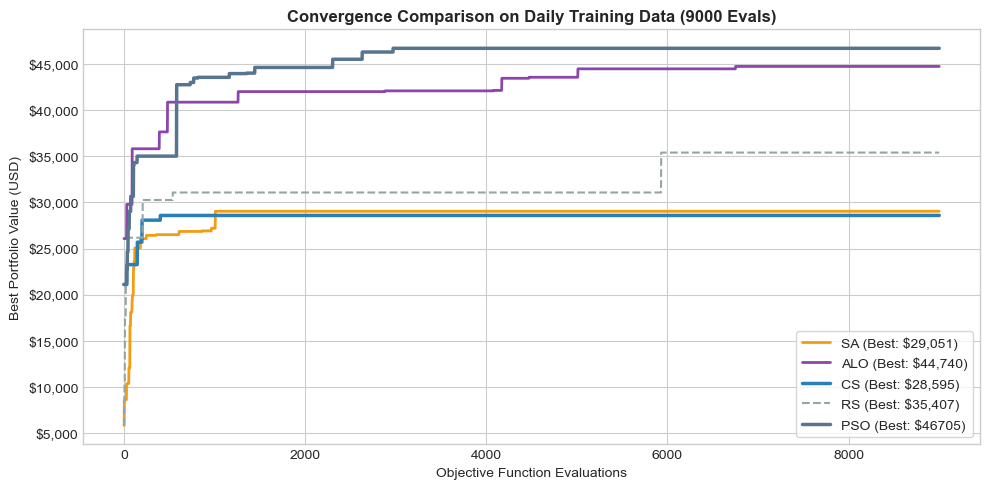

In [16]:
# Convergence comparison across optimisation algorithms
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.linspace(0, EVALUATION_BUDGET, len(sa_history)), sa_history, label=f'SA (Best: ${sa_train_fitness:,.0f})', color='#f39c12', linewidth=2)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(alo_history)), alo_history, label=f'ALO (Best: ${alo_train_fitness:,.0f})', color='#8e44ad', linewidth=2)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(cs_history)), cs_history, label=f'CS (Best: ${cs_train_fitness:,.0f})', color='#2980b9', linewidth=2.5)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(rs_history)), rs_history, label=f'RS (Best: ${rs_train_fitness:,.0f})', color='#95a5a6', linewidth=1.5, linestyle='--')
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(pso_history)), pso_history, label=f'PSO (Best: ${pso_train_fitness:.0f})', color='#577590', linewidth=2.5)

ax.set_xlabel('Objective Function Evaluations')
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title('Convergence Comparison on Daily Training Data (9000 Evals)', fontweight='bold')
ax.legend(frameon=True, facecolor='white')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

## 10. Experiment 2: Convergence Analysis on Hourly Training Data

This experiment evaluates the convergence behaviour of the optimisation algorithms using Bitcoin hourly training data.

Hourly data provides a medium-term market resolution that captures both short-term price fluctuations and broader intraday trends. This allows the optimisation algorithms to be evaluated under a more dynamic environment compared to daily data while remaining computationally manageable.

The experiment compares the convergence performance of Random Search (RS), Simulated Annealing (SA), Antlion Optimizer (ALO), Cuckoo Search (CS), and Particle Swarm Optimisation (PSO). The analysis focuses on optimisation stability, exploration capability, convergence speed, and the quality of the final trading solutions discovered by each algorithm.


In [17]:
# Experiment 2: Convergence analysis on hourly training data

# Use hourly Bitcoin training data
hourly_baseline_train_prices = hourly_train_prices

# Random Search
start_time = time.time()
rs_hourly_params, rs_hourly_train_fitness, rs_hourly_history = random_search(prices=hourly_baseline_train_prices,bounds=BOUNDS_14D,
    max_evals=EVALUATION_BUDGET)
rs_hourly_runtime = time.time() - start_time
print(f"RS completed in {rs_hourly_runtime:.2f} seconds")

# Simulated Annealing 
start_time = time.time()
sa_hourly_params, sa_hourly_train_fitness, sa_hourly_history = simulated_annealing( prices=hourly_baseline_train_prices, bounds=BOUNDS_14D,
    max_evals=EVALUATION_BUDGET)
sa_hourly_runtime = time.time() - start_time
print(f"SA completed in {sa_hourly_runtime:.2f} seconds")

# Antlion Optimizer
start_time = time.time()
alo_hourly_params, alo_hourly_train_fitness, alo_hourly_history = antlion_optimizer(prices=hourly_baseline_train_prices, bounds=BOUNDS_14D,
    n_agents=30, max_iter=300)
alo_hourly_runtime = time.time() - start_time
print(f"ALO completed in {alo_hourly_runtime:.2f} seconds")

# Cuckoo Search
start_time = time.time()
cs_hourly_params, cs_hourly_train_fitness, cs_hourly_history = cuckoo_search(prices=hourly_baseline_train_prices, bounds=BOUNDS_14D, 
    n_nests=30, max_iter=150)
cs_hourly_runtime = time.time() - start_time
print(f"CS completed in {cs_hourly_runtime:.2f} seconds")

# Particle Swarm Optimisation
start_time = time.time()
pso_hourly_params, pso_hourly_train_fitness, pso_hourly_history = particle_swarm_optimisation( bounds=BOUNDS_14D,
    max_evaluations=EVALUATION_BUDGET, swarm_size=30, inertia_weight=0.7, cognitive_coefficient=1.5, social_coefficient=1.5,
    fitness_function=lambda params: evaluate_fitness( params, hourly_baseline_train_prices))
pso_hourly_runtime = time.time() - start_time

print(f"PSO completed in {pso_hourly_runtime:.2f} seconds")
print("\nHourly optimisation complete.")

RS completed in 182.60 seconds
SA completed in 172.77 seconds
ALO completed in 173.11 seconds
CS completed in 176.98 seconds
PSO completed in 192.63 seconds

Hourly optimisation complete.


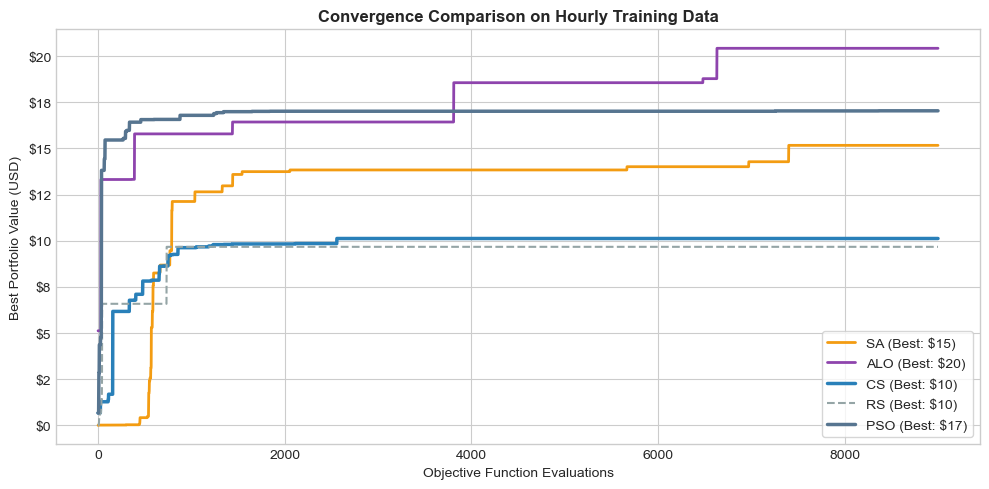

In [18]:
# Convergence comparison on hourly training data

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.linspace(0, EVALUATION_BUDGET, len(sa_hourly_history)),sa_hourly_history,label=f"SA (Best: ${sa_hourly_train_fitness:,.0f})",
        color="#f39c12",linewidth=2)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(alo_hourly_history)),alo_hourly_history,label=f"ALO (Best: ${alo_hourly_train_fitness:,.0f})",
        color="#8e44ad",linewidth=2)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(cs_hourly_history)),cs_hourly_history,label=f"CS (Best: ${cs_hourly_train_fitness:,.0f})",
        color="#2980b9",linewidth=2.5)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(rs_hourly_history)),rs_hourly_history,label=f"RS (Best: ${rs_hourly_train_fitness:,.0f})",
        color="#95a5a6",linewidth=1.5,linestyle="--")
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(pso_hourly_history)),pso_hourly_history,label=f"PSO (Best: ${pso_hourly_train_fitness:,.0f})",
        color="#577590",linewidth=2.5)

ax.set_xlabel("Objective Function Evaluations")
ax.set_ylabel("Best Portfolio Value (USD)")
ax.set_title("Convergence Comparison on Hourly Training Data",fontweight="bold")
ax.legend(frameon=True, facecolor="white")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'${value:,.0f}'))
plt.tight_layout()
plt.show()

The hourly-resolution experiments revealed a substantially higher computational complexity compared to the daily-data experiments. As shown in the convergence analysis, several optimisation algorithms required a significantly larger number of objective function evaluations to achieve stable convergence, resulting in longer execution times and increased computational resource usage.

Although hourly data provided a richer representation of short-term market dynamics, the optimisation process became considerably more expensive due to the larger search complexity and increased trading signal frequency. Based on these observations, the group decided to conduct the remaining optimisation experiments primarily using daily market data in order to maintain computational feasibility within the project timeframe.

Furthermore, minute-level experiments were not extensively pursued because their computational requirements and optimisation runtimes were expected to be substantially higher than those observed in the hourly-resolution experiments.

## 10. Experiment 3: Out-of-Sample Generalisation on Daily Test Data

This experiment evaluates the ability of the optimised trading strategies to generalise to unseen market conditions using the daily Bitcoin test dataset.

The algorithms were trained exclusively on historical data prior to 2020. The test dataset contains unseen Bitcoin market data from 2020 onwards, including highly volatile market conditions and major trend changes. This out-of-sample evaluation provides a more realistic assessment of predictive robustness and reduces the risk of overfitting.

The best parameter configuration discovered by each optimisation algorithm during training was evaluated on the unseen test dataset using the same portfolio backtesting framework.

The evaluated algorithms were:
- Random Search (RS),
- Simulated Annealing (SA),
- Antlion Optimizer (ALO),
- Cuckoo Search (CS),
- Particle Swarm Optimisation (PSO).

A Buy-and-Hold benchmark strategy was also included for comparison. The benchmark represents a passive investment strategy where Bitcoin is purchased at the beginning of the test period and held until the final observation.

Portfolio value trajectories were recorded throughout the entire test period to analyse:
- long-term profitability,
- stability of portfolio growth,
- robustness under volatile market conditions,
- and comparative generalisation performance across optimisation algorithms.

In [19]:
# Experiment 3: Out-of-sample generalisation on daily test data

INITIAL_CASH = 1000.0

# Use daily test data for out-of-sample evaluation
daily_test_price_series = daily_test_prices

# Evaluate optimised strategies on unseen test data
rs_test_value = evaluate_fitness(rs_params,daily_test_price_series,initial_cash=INITIAL_CASH)
sa_test_value = evaluate_fitness(sa_params,daily_test_price_series,initial_cash=INITIAL_CASH)
alo_test_value = evaluate_fitness(alo_params,daily_test_price_series,initial_cash=INITIAL_CASH)
cs_test_value = evaluate_fitness(cs_params,daily_test_price_series,initial_cash=INITIAL_CASH)
pso_test_value = evaluate_fitness(pso_params,daily_test_price_series,initial_cash=INITIAL_CASH)

# Buy-and-hold benchmark
buy_hold_test_value = (INITIAL_CASH *daily_test_price_series[-1] /daily_test_price_series[0])

print("OUT-OF-SAMPLE TEST VALUES")
print(f"RS  Test Value: ${rs_test_value:,.2f}")
print(f"SA  Test Value: ${sa_test_value:,.2f}")
print(f"ALO Test Value: ${alo_test_value:,.2f}")
print(f"CS  Test Value: ${cs_test_value:,.2f}")
print(f"PSO Test Value: ${pso_test_value:,.2f}")
print(f"Buy & Hold   : ${buy_hold_test_value:,.2f}")

OUT-OF-SAMPLE TEST VALUES
RS  Test Value: $2,107.29
SA  Test Value: $4,206.86
ALO Test Value: $2,234.04
CS  Test Value: $3,377.38
PSO Test Value: $2,722.49
Buy & Hold   : $6,015.80


In [20]:
def simulate_portfolio_curve(parameters, price_series, initial_cash=1000.0, fee=0.03):
    """ This function simulates the portfolio value curve for a trading strategy. """
    
    trading_signals, _, _ = generate_trading_signals(price_series,parameters)
    cash_balance = float(initial_cash)
    bitcoin_holdings = 0.0
    portfolio_values = []

    for time_index in range(len(price_series)):
        current_price = float(price_series[time_index])
        if trading_signals[time_index] == 1 and cash_balance > 0:  # Buy Bitcoin 
            bitcoin_holdings = (cash_balance * (1.0 - fee)) / current_price
            cash_balance = 0.0
        elif trading_signals[time_index] == -1 and bitcoin_holdings > 0: # Sell Bitcoin 
            cash_balance = (bitcoin_holdings *current_price *(1.0 - fee))
            bitcoin_holdings = 0.0

        current_portfolio_value = (cash_balance + bitcoin_holdings * current_price)
        portfolio_values.append(current_portfolio_value)

    return np.array(portfolio_values)

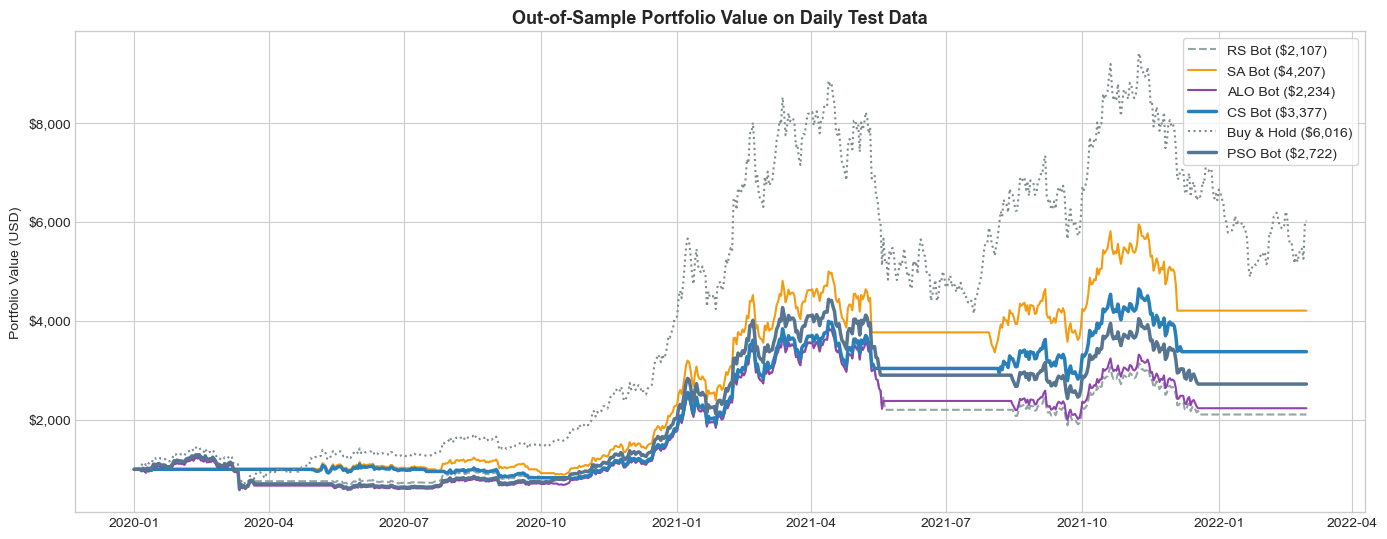

In [21]:
# Out-of-sample portfolio value trajectories

rs_test_curve = simulate_portfolio_curve(rs_params,daily_test_price_series,initial_cash=INITIAL_CASH)
sa_test_curve = simulate_portfolio_curve(sa_params,daily_test_price_series,initial_cash=INITIAL_CASH)
alo_test_curve = simulate_portfolio_curve(alo_params,daily_test_price_series,initial_cash=INITIAL_CASH)
cs_test_curve = simulate_portfolio_curve(cs_params,daily_test_price_series,initial_cash=INITIAL_CASH)
pso_test_curve = simulate_portfolio_curve(pso_params,daily_test_price_series,initial_cash=INITIAL_CASH)
buy_hold_test_curve = (INITIAL_CASH *daily_test_price_series /daily_test_price_series[0])

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(daily_test_df['date'],rs_test_curve,label=f"RS Bot (${rs_test_value:,.0f})",color="#95a5a6",linestyle="--",linewidth=1.5)
ax.plot(daily_test_df['date'],sa_test_curve,label=f"SA Bot (${sa_test_value:,.0f})",color="#f39c12",linewidth=1.5)
ax.plot(daily_test_df['date'],alo_test_curve,label=f"ALO Bot (${alo_test_value:,.0f})",color="#8e44ad",linewidth=1.5)
ax.plot(daily_test_df['date'],cs_test_curve,label=f"CS Bot (${cs_test_value:,.0f})",color="#2980b9",linewidth=2.5)
ax.plot(daily_test_df['date'],buy_hold_test_curve,label=f"Buy & Hold (${buy_hold_test_value:,.0f})",color="#7f8c8d",linestyle=":",linewidth=1.5)
ax.plot(daily_test_df['date'],pso_test_curve,label=f"PSO Bot (${pso_test_value:,.0f})",color="#577590",linewidth=2.5)

ax.set_title("Out-of-Sample Portfolio Value on Daily Test Data",fontsize=13,fontweight="bold")
ax.set_ylabel("Portfolio Value (USD)")
ax.legend(frameon=True, facecolor="white")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'${value:,.0f}'))
plt.tight_layout()
plt.show()

## 11. Visualising Trading Signal Behaviour

This section visualises how the optimised 14-dimensional trading strategies interact with Bitcoin market prices to generate buy and sell decisions on unseen test data.

For each optimisation algorithm, the following components are displayed:
- the Bitcoin price series,
- the fast composite indicator line,
- the slow composite indicator line,
- buy execution signals,
- and sell execution signals.

Trading decisions are generated when the fast composite indicator crosses the slow composite indicator:
- upward crossovers generate buy signals,
- downward crossovers generate sell signals.

These visualisations provide additional interpretability by illustrating how the discovered parameter configurations behave under real market conditions and how each algorithm structures trading activity over time.

In [22]:
# Visualising trading signal behaviour

def plot_trade_signals(price_series, dates, parameters, algorithm_name):
    """ This function visualises trading signals generated by the 14D trading engine."""

    trading_signals, fast_line, slow_line = generate_trading_signals(price_series,parameters)
    buy_indices = np.where(trading_signals == 1)[0]
    sell_indices = np.where(trading_signals == -1)[0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates,price_series,label="BTC Price",color="black",alpha=0.3,linewidth=1) # Plot Bitcoin price series
    ax.plot(dates,fast_line,label="Composite HIGH (Fast)",color="#2980b9",linewidth=1.5) # Plot fast composite indicator
    ax.plot(dates,slow_line,label="Composite LOW (Slow)",color="#e67e22",linewidth=1.5) # Plot slow composite indicator
    # Plot buy signals
    ax.scatter(dates[buy_indices],price_series[buy_indices],marker="^",color="green",s=100,zorder=5,label=f"Buy Signals ({len(buy_indices)})")
    # Plot sell signals
    ax.scatter(dates[sell_indices],price_series[sell_indices],marker="v",color="red",s=100,zorder=5,label=f"Sell Signals ({len(sell_indices)})")

    # Figure formatting
    ax.set_title(f"Trading Signal Execution: {algorithm_name}",fontsize=14,fontweight="bold")
    ax.set_ylabel("Price (USD)")
    ax.legend(loc="upper left",frameon=True,facecolor="white")
    plt.tight_layout()
    plt.show()

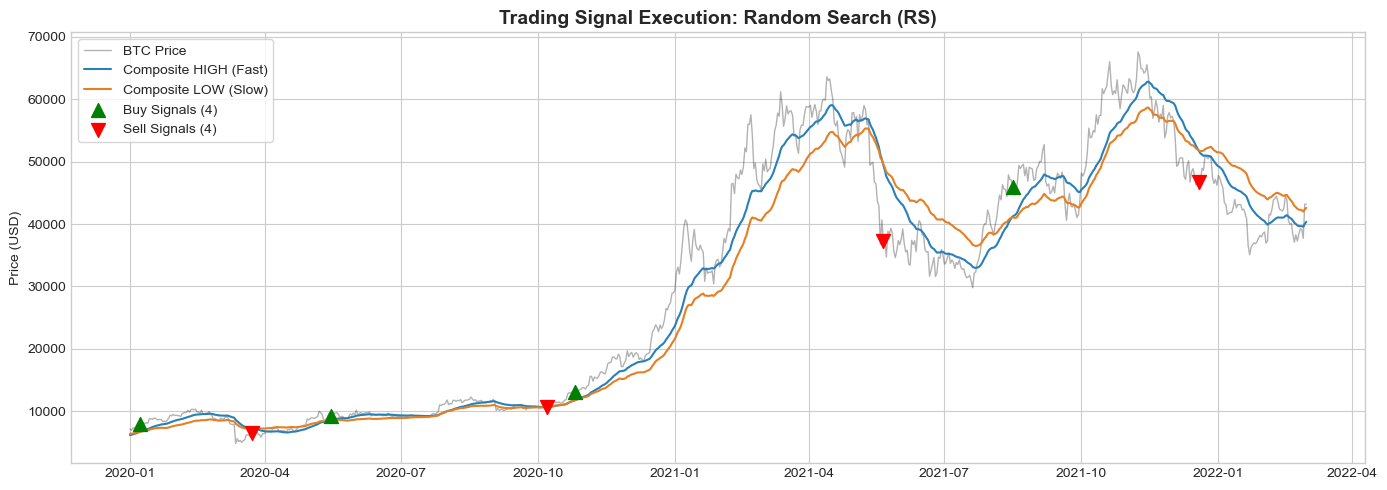

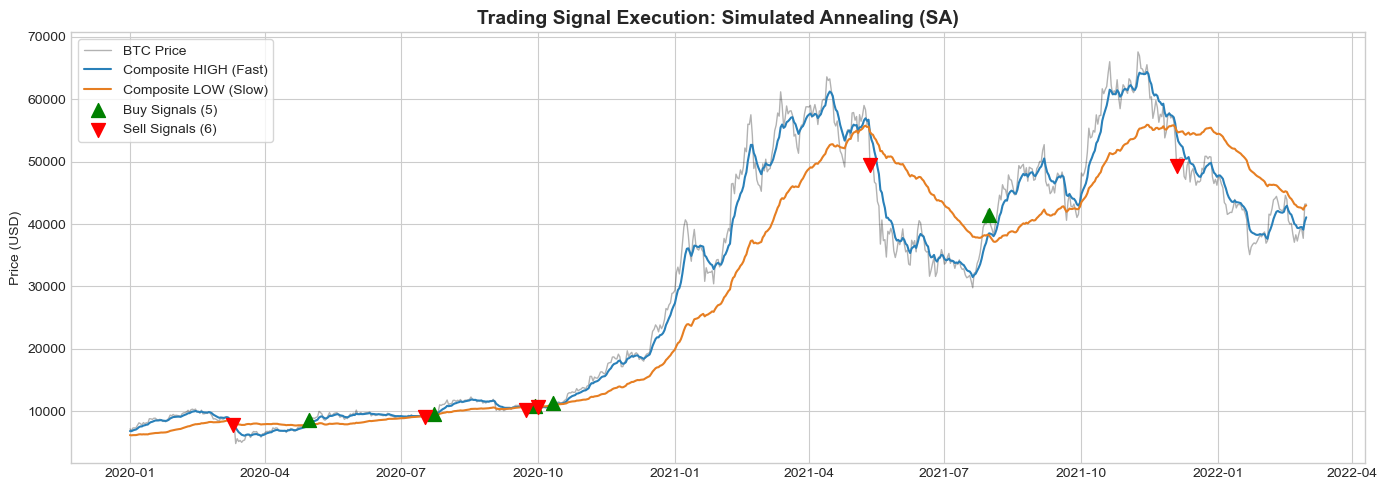

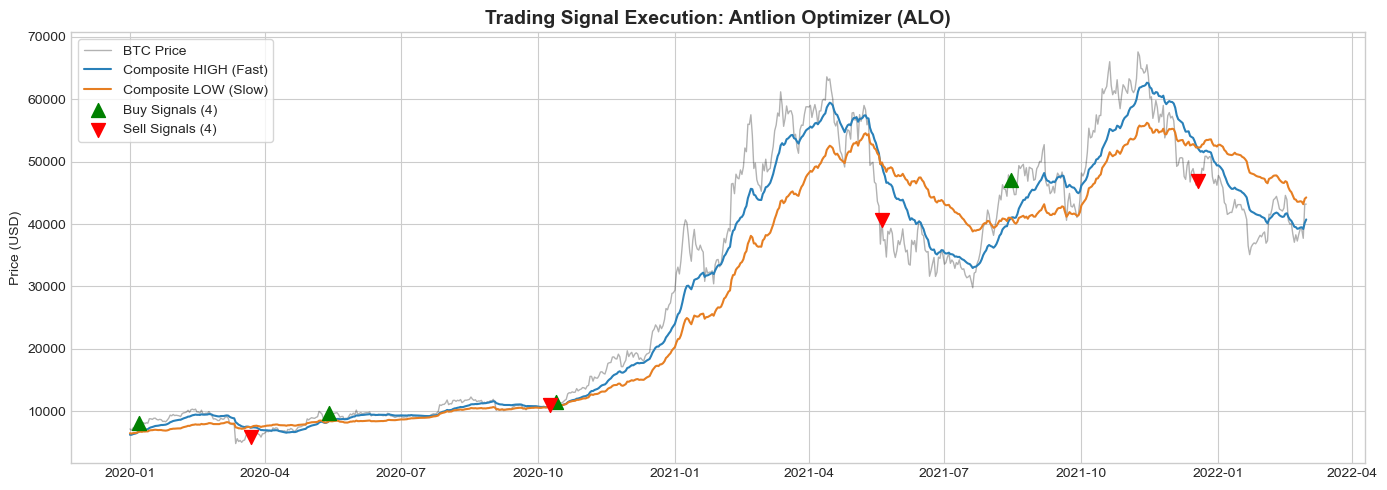

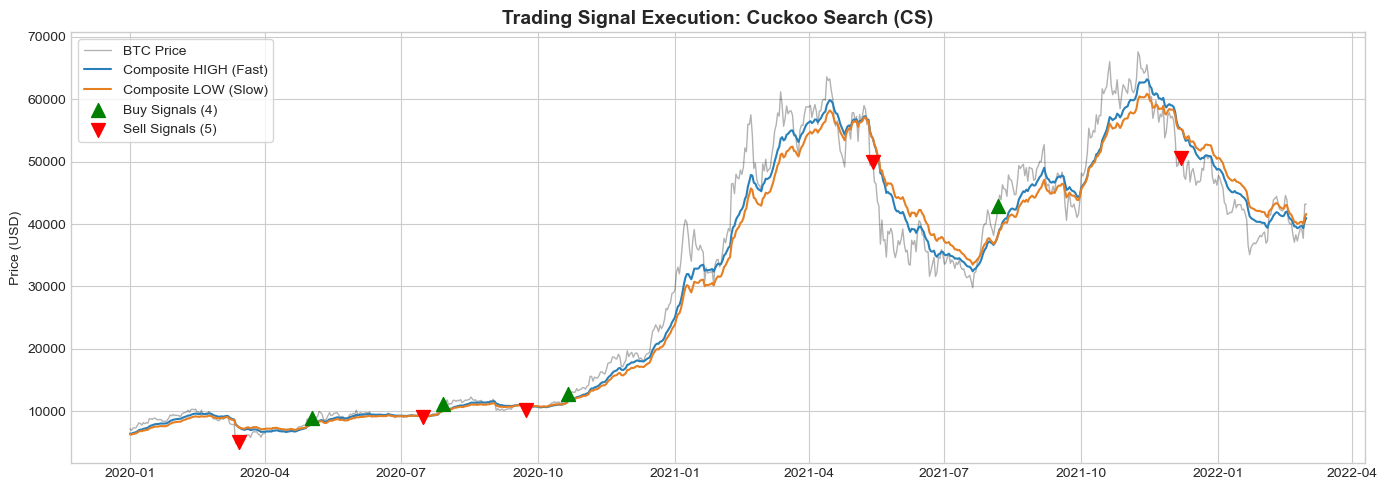

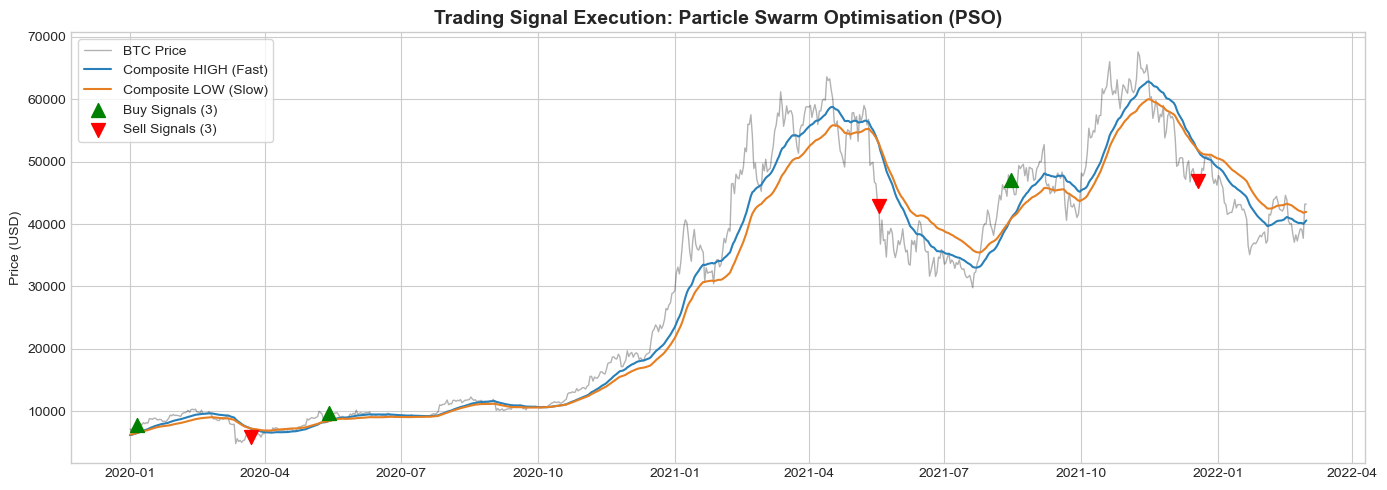

In [23]:
# Visualise trading behaviour for all algorithms

plot_trade_signals( daily_test_prices,daily_test_df['date'].values,rs_params,"Random Search (RS)")
plot_trade_signals(daily_test_prices,daily_test_df['date'].values,sa_params,"Simulated Annealing (SA)")
plot_trade_signals(daily_test_prices,daily_test_df['date'].values,alo_params,"Antlion Optimizer (ALO)")
plot_trade_signals(daily_test_prices,daily_test_df['date'].values,cs_params,"Cuckoo Search (CS)")
plot_trade_signals(daily_test_prices,daily_test_df['date'].values,pso_params,"Particle Swarm Optimisation (PSO)")

## 10. Executive Summary

In [24]:
# Executive summary of daily training and test performance

summary = pd.DataFrame({
    "Strategy / Algorithm": ["Random Search","Simulated Annealing","Antlion Optimizer","Cuckoo Search","Particle Swarm Optimisation","Buy & Hold"],
    "Training Final Value": [f"${rs_train_fitness:,.2f}",f"${sa_train_fitness:,.2f}",f"${alo_train_fitness:,.2f}",
        f"${cs_train_fitness:,.2f}",f"${pso_train_fitness:,.2f}","N/A"],
    "Testing Final Value": [f"${rs_test_value:,.2f}",f"${sa_test_value:,.2f}",f"${alo_test_value:,.2f}",f"${cs_test_value:,.2f}",
        f"${pso_test_value:,.2f}",f"${buy_hold_test_value:,.2f}"],
    "Out-of-Sample ROI (%)": [f"{((rs_test_value - INITIAL_CASH) / INITIAL_CASH) * 100:.1f}%",
        f"{((sa_test_value - INITIAL_CASH) / INITIAL_CASH) * 100:.1f}%",
        f"{((alo_test_value - INITIAL_CASH) / INITIAL_CASH) * 100:.1f}%",
        f"{((cs_test_value - INITIAL_CASH) / INITIAL_CASH) * 100:.1f}%",
        f"{((pso_test_value - INITIAL_CASH) / INITIAL_CASH) * 100:.1f}%",
        f"{((buy_hold_test_value - INITIAL_CASH) / INITIAL_CASH) * 100:.1f}%"]})

print(summary.to_string(index=False, justify="center"))

    Strategy / Algorithm    Training Final Value Testing Final Value Out-of-Sample ROI (%)
              Random Search      $35,407.04           $2,107.29              110.7%       
        Simulated Annealing      $29,050.56           $4,206.86              320.7%       
          Antlion Optimizer      $44,740.45           $2,234.04              123.4%       
              Cuckoo Search      $28,595.30           $3,377.38              237.7%       
Particle Swarm Optimisation      $46,704.77           $2,722.49              172.2%       
                 Buy & Hold             N/A           $6,015.80              501.6%       


## 13. Experiment 4: Multi-Segment Robustness Optimisation

This experiment re-runs the optimisation algorithms using the multi-segment fitness framework.

Instead of evaluating each candidate strategy on the full training period as a single sequence, the training data is divided into different market-regime segments. Each candidate solution is evaluated independently on each segment, and the average portfolio value is used as the final fitness score.

This approach encourages the algorithms to discover trading strategies that generalise across different market conditions, including sideways, bullish, bearish, and recovery periods.

In [25]:
# Experiment 4: Multi-segment robustness optimisation

# Use daily market-regime segments for robustness training
baseline_training_segments = daily_training_segments

# Multi-segment fitness evaluator
multi_segment_fitness_function = lambda params, prices=None: evaluate_multi_segment_fitness(params,baseline_training_segments)

print("MULTI-SEGMENT ROBUSTNESS OPTIMISATION")

# Random Search 
print("\n[RS] Running Random Search...")
start_time = time.time()
rs_ms_params, rs_ms_fitness, rs_ms_history = random_search(prices=None,bounds=BOUNDS_14D,max_evals=EVALUATION_BUDGET,
    fitness_fn=multi_segment_fitness_function)
rs_ms_runtime = time.time() - start_time
print(f"[RS] Completed in {rs_ms_runtime:.2f} seconds")

# Simulated Annealing
print("\n[SA] Running Simulated Annealing...")
start_time = time.time()
sa_ms_params, sa_ms_fitness, sa_ms_history = simulated_annealing(prices=None,bounds=BOUNDS_14D,max_evals=EVALUATION_BUDGET,
    fitness_fn=multi_segment_fitness_function)
sa_ms_runtime = time.time() - start_time
print(f"[SA] Completed in {sa_ms_runtime:.2f} seconds")

# Antlion Optimizer
print("\n[ALO] Running Antlion Optimizer...")
start_time = time.time()
alo_ms_params, alo_ms_fitness, alo_ms_history = antlion_optimizer(prices=None,bounds=BOUNDS_14D,n_agents=30,max_iter=300,
    fitness_fn=multi_segment_fitness_function)
alo_ms_runtime = time.time() - start_time
print(f"[ALO] Completed in {alo_ms_runtime:.2f} seconds")

# Cuckoo Search 
print("\n[CS] Running Cuckoo Search...")
start_time = time.time()
cs_ms_params, cs_ms_fitness, cs_ms_history = cuckoo_search(prices=None,bounds=BOUNDS_14D,n_nests=30,max_iter=150,
    fitness_fn=multi_segment_fitness_function)
cs_ms_runtime = time.time() - start_time
print(f"[CS] Completed in {cs_ms_runtime:.2f} seconds")

# Particle Swarm Optimisation
print("\n[PSO] Running Particle Swarm Optimisation...")
start_time = time.time()
pso_ms_params, pso_ms_fitness, pso_ms_history = particle_swarm_optimisation(bounds=BOUNDS_14D,max_evaluations=EVALUATION_BUDGET,swarm_size=30,
    inertia_weight=0.7,cognitive_coefficient=1.5,social_coefficient=1.5,fitness_function=multi_segment_fitness_function)
pso_ms_runtime = time.time() - start_time
print(f"[PSO] Completed in {pso_ms_runtime:.2f} seconds")

print("MULTI-SEGMENT OPTIMISATION COMPLETE")

MULTI-SEGMENT ROBUSTNESS OPTIMISATION

[RS] Running Random Search...
[RS] Completed in 30.03 seconds

[SA] Running Simulated Annealing...
[SA] Completed in 32.61 seconds

[ALO] Running Antlion Optimizer...
[ALO] Completed in 35.15 seconds

[CS] Running Cuckoo Search...
[CS] Completed in 36.12 seconds

[PSO] Running Particle Swarm Optimisation...
[PSO] Completed in 32.34 seconds
MULTI-SEGMENT OPTIMISATION COMPLETE


## 14. Comparing Single-Segment and Multi-Segment Optimisation

This experiment compares the convergence behaviour of single-segment optimisation against multi-segment optimisation.

Dashed lines represent the original single-segment optimisation results obtained from the full training sequence, while solid lines represent the multi-segment robustness optimisation results.

The comparison illustrates how enforcing robustness across different market regimes influences convergence behaviour, search stability, and final portfolio performance.

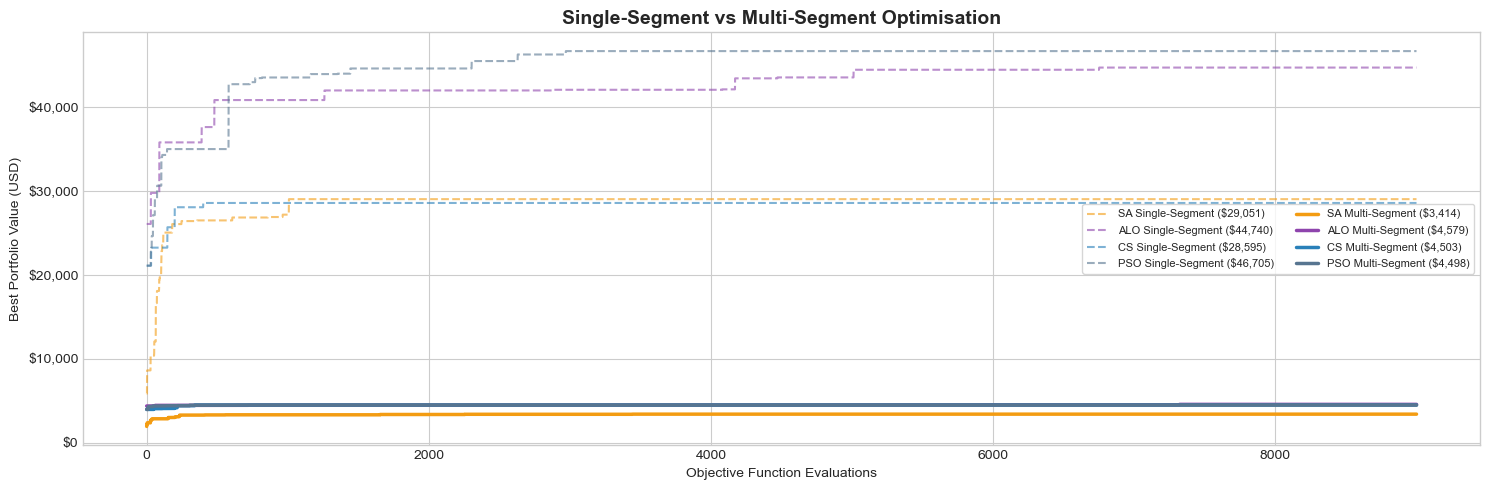

In [26]:
# Compare single-segment vs multi-segment optimisation

fig, ax = plt.subplots(figsize=(15, 5))

# Single-segment histories (dashed)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(sa_history)),sa_history,linestyle='--',linewidth=1.5,color='#f39c12',alpha=0.6,
    label=f'SA Single-Segment (${max(sa_history):,.0f})')
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(alo_history)),alo_history,linestyle='--',linewidth=1.5,color='#8e44ad',alpha=0.6,
    label=f'ALO Single-Segment (${max(alo_history):,.0f})')
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(cs_history)),cs_history,linestyle='--',linewidth=1.5,color='#2980b9',alpha=0.6,
    label=f'CS Single-Segment (${max(cs_history):,.0f})')
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(pso_history)),pso_history,linestyle='--',linewidth=1.5,color='#577590',alpha=0.6,
    label=f'PSO Single-Segment (${max(pso_history):,.0f})')

# Multi-segment histories (solid)
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(sa_ms_history)),sa_ms_history,linewidth=2.5,color='#f39c12',
    label=f'SA Multi-Segment (${max(sa_ms_history):,.0f})')
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(alo_ms_history)),alo_ms_history,linewidth=2.5,color='#8e44ad',
    label=f'ALO Multi-Segment (${max(alo_ms_history):,.0f})')
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(cs_ms_history)),cs_ms_history,linewidth=2.5,color='#2980b9',
    label=f'CS Multi-Segment (${max(cs_ms_history):,.0f})')
ax.plot(np.linspace(0, EVALUATION_BUDGET, len(pso_ms_history)),pso_ms_history,linewidth=2.5,color='#577590',
    label=f'PSO Multi-Segment (${max(pso_ms_history):,.0f})')

# Formatting
ax.set_xlabel('Objective Function Evaluations')
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title('Single-Segment vs Multi-Segment Optimisation',fontsize=14,fontweight='bold')
ax.legend(frameon=True,facecolor='white',fontsize=8,ncol=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

In [27]:
# Comparison: single-sequence vs multi-segment performance

# Evaluate multi-segment optimised parameters on the daily test set
rs_ms_test_value = evaluate_fitness(rs_ms_params,daily_test_prices,initial_cash=INITIAL_CASH)
sa_ms_test_value = evaluate_fitness(sa_ms_params,daily_test_prices,initial_cash=INITIAL_CASH)
alo_ms_test_value = evaluate_fitness(alo_ms_params,daily_test_prices,initial_cash=INITIAL_CASH)
cs_ms_test_value = evaluate_fitness(cs_ms_params,daily_test_prices,initial_cash=INITIAL_CASH)
pso_ms_test_value = evaluate_fitness(pso_ms_params,daily_test_prices,initial_cash=INITIAL_CASH)

# Build comparison table
comparison = pd.DataFrame({
    "Algorithm": ["Random Search","Simulated Annealing","Antlion Optimizer","Cuckoo Search","Particle Swarm Optimisation","Buy & Hold"],
    "Single-Segment Train ($)": [f"${rs_train_fitness:,.0f}",f"${sa_train_fitness:,.0f}",f"${alo_train_fitness:,.0f}",f"${cs_train_fitness:,.0f}",
        f"${pso_train_fitness:,.0f}","N/A"],
    "Multi-Segment Train ($)": [f"${rs_ms_fitness:,.0f}",f"${sa_ms_fitness:,.0f}",f"${alo_ms_fitness:,.0f}",f"${cs_ms_fitness:,.0f}",
        f"${pso_ms_fitness:,.0f}","N/A"],
    "Single-Segment Test ($)": [f"${rs_test_value:,.0f}",f"${sa_test_value:,.0f}",f"${alo_test_value:,.0f}",f"${cs_test_value:,.0f}",
        f"${pso_test_value:,.0f}",f"${buy_hold_test_value:,.0f}"],
    "Multi-Segment Test ($)": [f"${rs_ms_test_value:,.0f}",f"${sa_ms_test_value:,.0f}",f"${alo_ms_test_value:,.0f}",f"${cs_ms_test_value:,.0f}",
        f"${pso_ms_test_value:,.0f}",f"${buy_hold_test_value:,.0f}"]})

print(comparison.to_string(index=False))

                  Algorithm Single-Segment Train ($) Multi-Segment Train ($) Single-Segment Test ($) Multi-Segment Test ($)
              Random Search                  $35,407                  $4,473                  $2,107                 $4,143
        Simulated Annealing                  $29,051                  $3,414                  $4,207                 $3,381
          Antlion Optimizer                  $44,740                  $4,579                  $2,234                 $4,971
              Cuckoo Search                  $28,595                  $4,503                  $3,377                 $5,495
Particle Swarm Optimisation                  $46,705                  $4,498                  $2,722                 $4,712
                 Buy & Hold                      N/A                     N/A                  $6,016                 $6,016


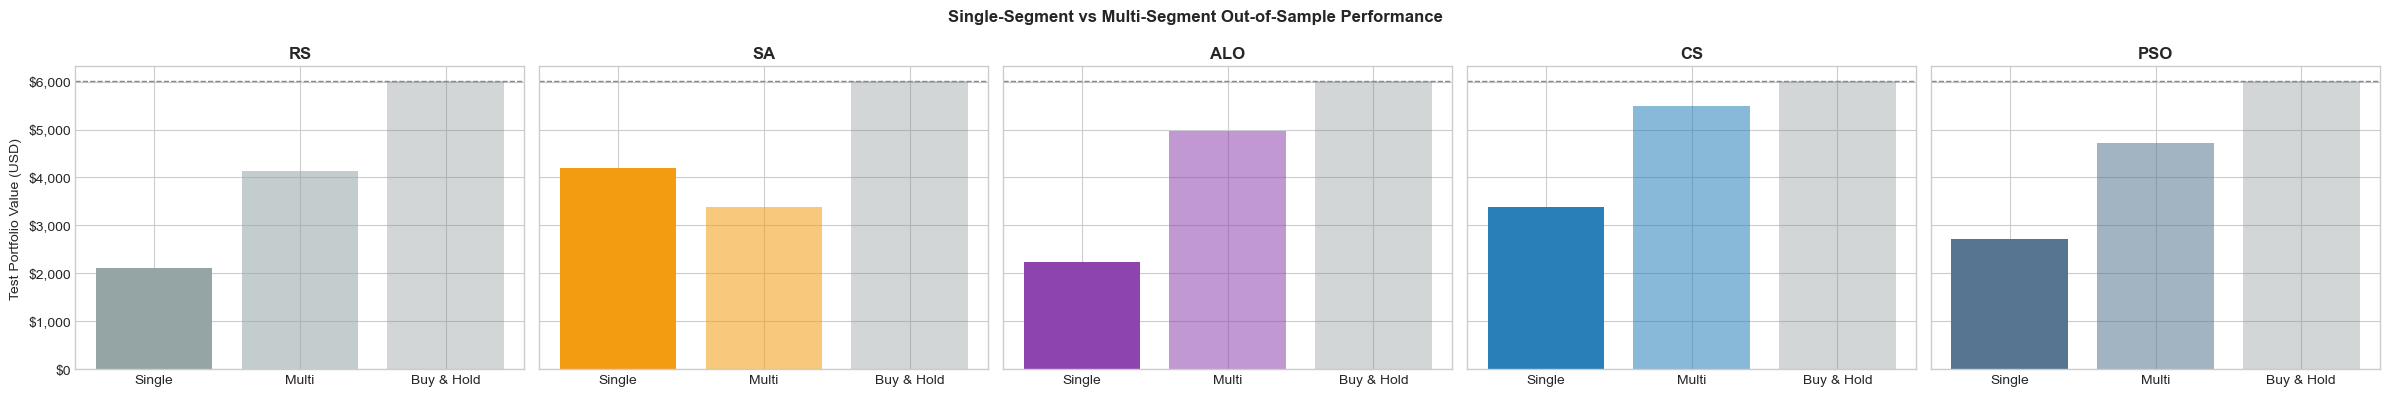

In [28]:
# Visual comparison of test performance

fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=True)
algorithms = [("RS", rs_test_value, rs_ms_test_value, "#95a5a6"),("SA", sa_test_value, sa_ms_test_value, "#f39c12"),
    ("ALO", alo_test_value, alo_ms_test_value, "#8e44ad"),("CS", cs_test_value, cs_ms_test_value, "#2980b9"),
    ("PSO", pso_test_value, pso_ms_test_value, "#577590")]

for ax, (algorithm_name, single_test_value, multi_test_value, color) in zip(axes, algorithms):
    bars = ax.bar(["Single", "Multi", "Buy & Hold"],[single_test_value, multi_test_value, buy_hold_test_value],color=[color, color, "#7f8c8d"])

    # Make multi-segment and benchmark bars slightly transparent
    bars[1].set_alpha(0.55)
    bars[2].set_alpha(0.35)
    ax.set_title(algorithm_name,fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'${value:,.0f}'))
    ax.axhline(buy_hold_test_value,color="#7f8c8d",linestyle="--",linewidth=1)
    
axes[0].set_ylabel("Test Portfolio Value (USD)")
plt.suptitle("Single-Segment vs Multi-Segment Out-of-Sample Performance",fontweight="bold")
plt.tight_layout()
plt.show()